In [1]:
#cell 1
import os
import sys
import time
import math
import random
import glob
from pathlib import Path

# Install timm quietly if missing
try:
    import timm
except ImportError:
    !pip install -q timm
    import timm

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print(f"PyTorch Version : {torch.__version__}")
print(f"timm Version    : {timm.__version__}")

PyTorch Version : 2.10.0+cpu
timm Version    : 1.0.26


In [2]:
#cell 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\n" + "="*50)
print("HARDWARE ACCELERATION")
print("="*50)
if torch.cuda.is_available():
    print(f"Device Name      : {torch.cuda.get_device_name(0)}")
    print(f"Device Count     : {torch.cuda.device_count()}")
    print(f"CUDA Version     : {torch.version.cuda}")
    print(f"cuDNN Enabled    : {torch.backends.cudnn.enabled}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"Total VRAM       : {total_mem:.2f} GB")
else:
    print("WARNING: CUDA is NOT available. Falling back to CPU.")
print(f"Active Device    : {device}")
print("="*50)



HARDWARE ACCELERATION
Active Device    : cpu


In [4]:
#cell3 
# Standard target classes in LC25000 lung subset
CLASS_NAMES = ["lung_aca", "lung_n", "lung_scc"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for idx, name in enumerate(CLASS_NAMES)}

def find_lung_dataset_root():
    """
    Search recursively within /kaggle/input for the LC25000 lung dataset folders.
    Returns the path to the directory containing lung_aca, lung_n, lung_scc.
    """
    search_roots = ["/kaggle/input", "./", "../input"]
    for base in search_roots:
        if not os.path.exists(base):
            continue
        for root, dirs, _ in os.walk(base):
            if all(cls_name in dirs for cls_name in CLASS_NAMES):
                return Path(root)
    raise FileNotFoundError(
        "Could not locate the LC25000 lung dataset directory containing "
        f"{CLASS_NAMES}. Please ensure the dataset is attached to your Kaggle notebook."
    )

dataset_root = find_lung_dataset_root()
print(f"\n[INFO] Dataset located at: {dataset_root}")

# Collect all file paths and labels
all_file_paths = []
all_labels = []

for cls_name in CLASS_NAMES:
    cls_folder = dataset_root / cls_name
    img_paths = sorted(
        glob.glob(str(cls_folder / "*.jpeg")) +
        glob.glob(str(cls_folder / "*.jpg")) +
        glob.glob(str(cls_folder / "*.png"))
    )
    for p in img_paths:
        all_file_paths.append(p)
        all_labels.append(CLASS_TO_IDX[cls_name])

all_file_paths = np.array(all_file_paths)
all_labels = np.array(all_labels)

# Verify image counts
total_images = len(all_file_paths)
assert total_images == 15000, f"Expected 15,000 images, but found {total_images}."


[INFO] Dataset located at: /kaggle/input/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets


In [5]:
#cell 4
print("\n" + "="*50)
print("DATASET CLASS DISTRIBUTION (LC25000 Lung Subset)")
print("="*50)
class_distribution = []
for cls_name in CLASS_NAMES:
    idx = CLASS_TO_IDX[cls_name]
    count = np.sum(all_labels == idx)
    class_distribution.append({
        "Class Label": idx,
        "Class Identifier": cls_name,
        "Medical Description": {
            "lung_aca": "Lung Adenocarcinoma",
            "lung_n": "Benign/Normal Lung Tissue",
            "lung_scc": "Lung Squamous Cell Carcinoma"
        }[cls_name],
        "Image Count": count
    })

df_dist = pd.DataFrame(class_distribution)
print(df_dist.to_string(index=False))
print(f"\nTotal Dataset Images: {total_images}")
print("="*50)


DATASET CLASS DISTRIBUTION (LC25000 Lung Subset)
 Class Label Class Identifier          Medical Description  Image Count
           0         lung_aca          Lung Adenocarcinoma         5000
           1           lung_n    Benign/Normal Lung Tissue         5000
           2         lung_scc Lung Squamous Cell Carcinoma         5000

Total Dataset Images: 15000


In [6]:
#cell 5
SEED = 42
print(f"\n[REPRODUCIBILITY] Setting random seed: {SEED}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)


[REPRODUCIBILITY] Setting random seed: 42


In [7]:
#cell 6
# 70% Train = 10,500 images (3,500 per class)
# 30% Test  =  4,500 images (1,500 per class)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_file_paths,
    all_labels,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
    stratify=all_labels
)

print("\n" + "="*50)
print("FIXED STRATIFIED 70/30 SPLIT SUMMARY")
print("="*50)
print(f"Total Training Images : {len(train_paths)} (70%)")
print(f"Total Testing Images  : {len(test_paths)} (30%)")
for idx, name in IDX_TO_CLASS.items():
    tr_count = np.sum(train_labels == idx)
    te_count = np.sum(test_labels == idx)
    print(f"  - {name:<10}: Train={tr_count:4d} | Test={te_count:4d}")
print("="*50)



FIXED STRATIFIED 70/30 SPLIT SUMMARY
Total Training Images : 10500 (70%)
Total Testing Images  : 4500 (30%)
  - lung_aca  : Train=3500 | Test=1500
  - lung_n    : Train=3500 | Test=1500
  - lung_scc  : Train=3500 | Test=1500


In [9]:
#cell 7
class LC25000Dataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        image = Image.open(path).convert("RGB")
        label = self.labels[idx]

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# Transforms
non_aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

aug_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=(-20, 20)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Non-augmented datasets
train_dataset_nonaug = LC25000Dataset(train_paths, train_labels, transform=non_aug_transform)
test_dataset = LC25000Dataset(test_paths, test_labels, transform=non_aug_transform)

BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader_nonaug = DataLoader(
    train_dataset_nonaug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
print("*")

*


In [10]:
#cell 8

import os
import socket
import warnings
import torch
import timm

def is_internet_available(host="8.8.8.8", port=53, timeout=2):
    """Quick check to avoid long Hugging Face connection timeouts if offline."""
    try:
        socket.setdefaulttimeout(timeout)
        socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect((host, port))
        return True
    except (socket.timeout, OSError):
        return False

def build_ghostnet100(num_classes=3, weights_path=None):
    """
    Builds GhostNet-100:
    - If weights_path is provided and exists, loads from disk.
    - If internet is active, pulls ImageNet weights from Hugging Face.
    - Otherwise, initializes without pretrained weights (pretrained=False).
    """
    # 1. Local weight checkpoint (e.g. from Kaggle input dataset)
    if weights_path and os.path.exists(weights_path):
        print(f"[INFO] Loading local weights from: {weights_path}")
        model = timm.create_model("ghostnet_100", pretrained=False, num_classes=num_classes)
        state_dict = torch.load(weights_path, map_location="cpu")
        # Strip classifier layer in case source had 1000 classes
        state_dict = {k: v for k, v in state_dict.items() if not k.startswith("classifier")}
        model.load_state_dict(state_dict, strict=False)
        return model

    # 2. Check internet before calling timm pretrained
    if is_internet_available():
        try:
            model = timm.create_model("ghostnet_100", pretrained=True, num_classes=num_classes)
            print("[INFO] Successfully loaded pretrained GhostNet-100 from Hugging Face.")
            return model
        except Exception as e:
            print(f"[WARNING] Download failed ({e}). Initializing without pretrained weights.")
    else:
        print("[WARNING] No internet access detected. Initializing GhostNet-100 with random weights.")
        print("          (To use ImageNet pretrained weights, enable 'Internet' in Kaggle Notebook Settings).")

    # 3. Offline fallback
    return timm.create_model("ghostnet_100", pretrained=False, num_classes=num_classes)

print("\n" + "="*50)
print("MODEL ARCHITECTURE VERIFICATION")
print("="*50)

sample_model = build_ghostnet100(num_classes=3)
total_params = sum(p.numel() for p in sample_model.parameters())
trainable_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)
param_size_mb = sum(p.numel() * p.element_size() for p in sample_model.parameters()) / (1024**2)

print(f"Classification Head Structure : {sample_model.get_classifier()}")
print(f"Total Parameters             : {total_params:,}")
print(f"Trainable Parameters         : {trainable_params:,}")
print(f"Model Parameter Size in RAM  : {param_size_mb:.2f} MB")
print("="*50)


MODEL ARCHITECTURE VERIFICATION
[WARNING] No internet access detected. Initializing GhostNet-100 with random weights.
          (To use ImageNet pretrained weights, enable 'Internet' in Kaggle Notebook Settings).
Classification Head Structure : Linear(in_features=1280, out_features=3, bias=True)
Total Parameters             : 3,905,351
Trainable Parameters         : 3,905,351
Model Parameter Size in RAM  : 14.90 MB


In [11]:
#cell 9
def train_model(model, train_loader, optimizer, criterion, epochs=8, desc="Training"):
    model.to(device)
    history = {"train_loss": [], "train_acc": [], "epoch_times": []}

    print(f"\n--- Starting {desc} ({epochs} Epochs) ---")
    start_total_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        model.train()

        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for images, targets in train_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == targets.data).item()
            total_samples += images.size(0)

        epoch_time = time.perf_counter() - epoch_start
        epoch_loss = running_loss / total_samples
        epoch_acc = (running_corrects / total_samples) * 100.0

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        history["epoch_times"].append(epoch_time)

        print(
            f"Epoch [{epoch}/{epochs}] | "
            f"Train Loss: {epoch_loss:.5f} | "
            f"Train Acc: {epoch_acc:.2f}% | "
            f"Time: {epoch_time:.2f}s"
        )

    total_training_time = time.perf_counter() - start_total_time
    print(f"Total Training Elapsed Time: {total_training_time:.2f}s "
          f"(Avg: {np.mean(history['epoch_times']):.2f}s/epoch)")
    return history


def evaluate_model(model, test_loader):
    model.eval()
    model.to(device)

    all_targets = []
    all_preds = []
    all_probs = []

    # Warm-up pass
    with torch.no_grad():
        for i, (images, _) in enumerate(test_loader):
            images = images.to(device)
            _ = model(images)
            if i >= 2:
                break

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_inf = time.perf_counter()

    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    total_inf_time = time.perf_counter() - start_inf

    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    num_test_samples = len(all_targets)
    avg_inf_time_per_image_ms = (total_inf_time / num_test_samples) * 1000.0

    # Specificity per class: TN / (TN + FP)
    cm = confusion_matrix(all_targets, all_preds)
    specificities = []
    for i in range(len(CLASS_NAMES)):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec_i = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(spec_i)
    macro_specificity = np.mean(specificities)

    acc = accuracy_score(all_targets, all_preds)
    prec_macro = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    prec_weighted = precision_score(all_targets, all_preds, average="weighted", zero_division=0)
    rec_macro = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    rec_weighted = recall_score(all_targets, all_preds, average="weighted", zero_division=0)
    f1_macro = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    f1_weighted = f1_score(all_targets, all_preds, average="weighted", zero_division=0)

    try:
        roc_auc_macro = roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro")
    except Exception:
        roc_auc_macro = float("nan")

    return {
        "accuracy": acc,
        "precision_macro": prec_macro,
        "precision_weighted": prec_weighted,
        "recall_macro": rec_macro,
        "recall_weighted": rec_weighted,
        "specificity_macro": macro_specificity,
        "per_class_specificity": specificities,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc_macro": roc_auc_macro,
        "confusion_matrix": cm,
        "classification_report": classification_report(all_targets, all_preds, target_names=CLASS_NAMES, digits=6),
        "avg_inference_time_ms": avg_inf_time_per_image_ms,
        "all_targets": all_targets,
        "all_preds": all_preds,
        "all_probs": all_probs
    }


In [12]:
#cell 10
seed_everything(SEED)
model_nonaug = build_ghostnet100(num_classes=3)

EPOCHS = 8
LR = 0.001
BETA1 = 0.9
BETA2 = 0.999

optimizer_nonaug = optim.Adam(model_nonaug.parameters(), lr=LR, betas=(BETA1, BETA2))
criterion = nn.CrossEntropyLoss()

history_nonaug = train_model(
    model_nonaug,
    train_loader_nonaug,
    optimizer_nonaug,
    criterion,
    epochs=EPOCHS,
    desc="GhostNet-100 (Non-Augmented Baseline)"
)

results_nonaug = evaluate_model(model_nonaug, test_loader)

print("\n" + "="*60)
print("EVALUATION METRICS: GHOSTNET-100 (NON-AUGMENTED)")
print("="*60)
print(f"Test Accuracy                     : {results_nonaug['accuracy'] * 100:.4f}%")
print(f"Macro Precision                   : {results_nonaug['precision_macro'] * 100:.4f}%")
print(f"Weighted Precision                : {results_nonaug['precision_weighted'] * 100:.4f}%")
print(f"Macro Recall / Sensitivity        : {results_nonaug['recall_macro'] * 100:.4f}%")
print(f"Weighted Recall                   : {results_nonaug['recall_weighted'] * 100:.4f}%")
print(f"Macro Specificity                 : {results_nonaug['specificity_macro'] * 100:.4f}%")
for i, name in enumerate(CLASS_NAMES):
    print(f"  - Specificity ({name:<8})       : {results_nonaug['per_class_specificity'][i] * 100:.4f}%")
print(f"Macro F1-Score                    : {results_nonaug['f1_macro'] * 100:.4f}%")
print(f"Weighted F1-Score                 : {results_nonaug['f1_weighted'] * 100:.4f}%")
print(f"Multiclass ROC-AUC (Macro OVR)    : {results_nonaug['roc_auc_macro']:.6f}")
print(f"Final Training Loss (Epoch {EPOCHS})     : {history_nonaug['train_loss'][-1]:.6f}")
print(f"Average Epoch Training Time       : {np.mean(history_nonaug['epoch_times']):.2f} s")
print(f"Average Inference Time Per Image  : {results_nonaug['avg_inference_time_ms']:.4f} ms")
print(f"Number of Trainable Parameters    : {trainable_params:,}")
print(f"Model Memory Footprint (RAM)      : {param_size_mb:.2f} MB")
print("\nClassification Report:\n" + results_nonaug['classification_report'])
print("Confusion Matrix:\n", results_nonaug['confusion_matrix'])

# Delta comparison with paper
paper_acc_nonaug = 99.95
diff_nonaug = (results_nonaug['accuracy'] * 100.0) - paper_acc_nonaug
print("\n" + "-"*60)
print("COMPARISON WITH PAPER REFERENCE (Non-Augmented GhostNet-100)")
print(f"  Reproduction Accuracy : {results_nonaug['accuracy'] * 100.0:.4f}%")
print(f"  Paper Reported Acc    : {paper_acc_nonaug:.2f}%")
print(f"  Discrepancy (Delta)   : {diff_nonaug:+.4f}%")
print("-"*60)

[WARNING] No internet access detected. Initializing GhostNet-100 with random weights.
          (To use ImageNet pretrained weights, enable 'Internet' in Kaggle Notebook Settings).

--- Starting GhostNet-100 (Non-Augmented Baseline) (8 Epochs) ---
Epoch [1/8] | Train Loss: 0.29881 | Train Acc: 87.89% | Time: 484.86s
Epoch [2/8] | Train Loss: 0.19556 | Train Acc: 92.50% | Time: 468.19s
Epoch [3/8] | Train Loss: 0.14880 | Train Acc: 94.39% | Time: 470.66s
Epoch [4/8] | Train Loss: 0.14069 | Train Acc: 94.50% | Time: 470.79s
Epoch [5/8] | Train Loss: 0.12681 | Train Acc: 95.05% | Time: 497.22s
Epoch [6/8] | Train Loss: 0.11330 | Train Acc: 95.97% | Time: 512.06s
Epoch [7/8] | Train Loss: 0.09241 | Train Acc: 96.77% | Time: 469.33s
Epoch [8/8] | Train Loss: 0.07214 | Train Acc: 97.29% | Time: 475.76s
Total Training Elapsed Time: 3848.87s (Avg: 481.11s/epoch)

EVALUATION METRICS: GHOSTNET-100 (NON-AUGMENTED)
Test Accuracy                     : 97.6667%
Macro Precision                   : 97

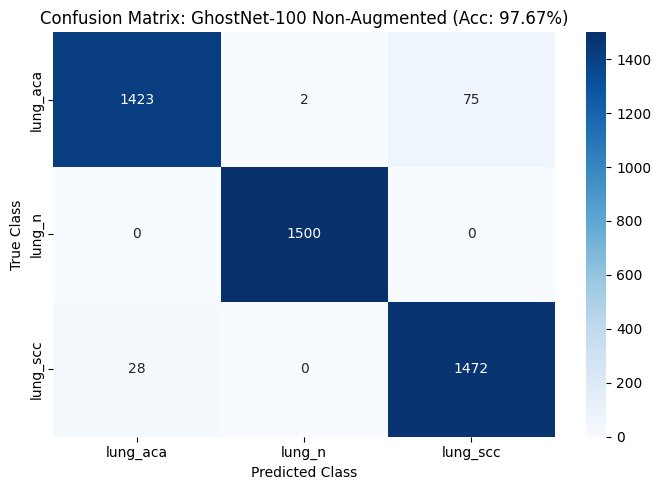

In [13]:
#cell 11
plt.figure(figsize=(7, 5))
sns.heatmap(
    results_nonaug['confusion_matrix'],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=True
)
plt.title(f"Confusion Matrix: GhostNet-100 Non-Augmented (Acc: {results_nonaug['accuracy']*100:.2f}%)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig("confusion_matrix_nonaug.png", dpi=300)
plt.show()

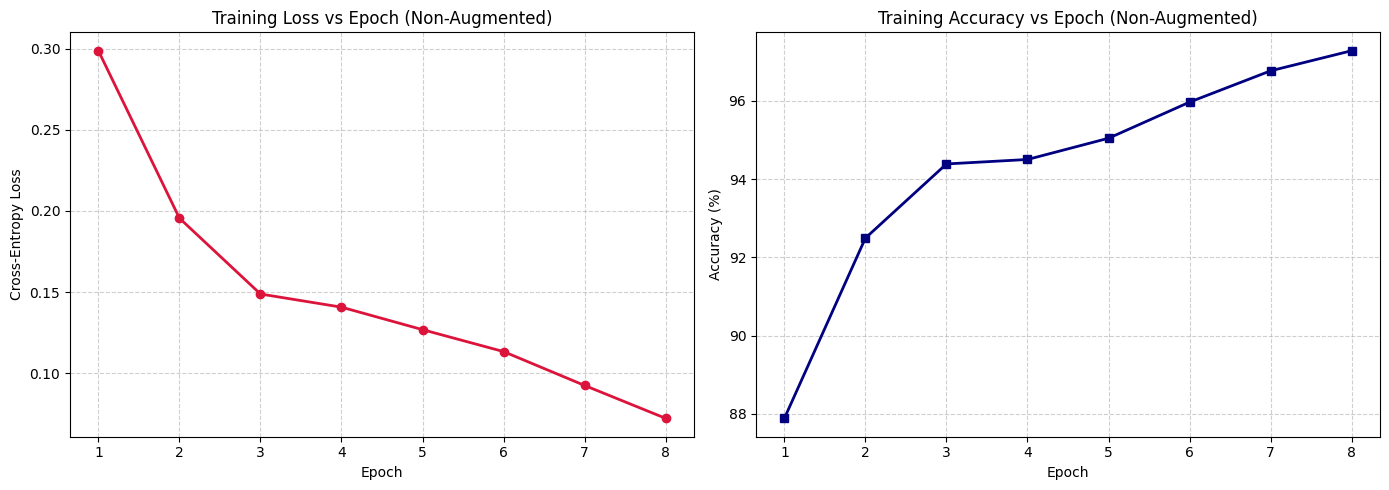


[SAVED] Saved baseline model to 'ghostnet_100_non_augmented.pth' (15.16 MB)


In [14]:
#cell 12
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(range(1, EPOCHS + 1), history_nonaug['train_loss'], marker='o', color='crimson', lw=2)
ax1.set_title("Training Loss vs Epoch (Non-Augmented)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, linestyle="--", alpha=0.6)

# Accuracy plot
ax2.plot(range(1, EPOCHS + 1), history_nonaug['train_acc'], marker='s', color='navy', lw=2)
ax2.set_title("Training Accuracy vs Epoch (Non-Augmented)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("training_curves_nonaug.png", dpi=300)
plt.show()

# Save checkpoint
torch.save(model_nonaug.state_dict(), "ghostnet_100_non_augmented.pth")
file_size_mb = os.path.getsize("ghostnet_100_non_augmented.pth") / (1024**2)
print(f"\n[SAVED] Saved baseline model to 'ghostnet_100_non_augmented.pth' ({file_size_mb:.2f} MB)")

In [16]:
#cell 13
print("\n" + "="*50)
print("PREPARING AUGMENTED EXPERIMENT (21,000 Training Samples)")
print("="*50)

# 10,500 non-augmented samples + 10,500 augmented samples
train_part_orig = LC25000Dataset(train_paths, train_labels, transform=non_aug_transform)
train_part_aug = LC25000Dataset(train_paths, train_labels, transform=aug_train_transform)

train_dataset_augmented_doubled = ConcatDataset([train_part_orig, train_part_aug])

print(f"Augmented Training Set Size : {len(train_dataset_augmented_doubled):,} images")
print(f"Test Set Size (Unchanged)   : {len(test_dataset):,} images")
assert len(train_dataset_augmented_doubled) == 21000, "Augmented train size must equal 21,000"

train_loader_aug = DataLoader(
    train_dataset_augmented_doubled,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=torch.cuda.is_available()
)


PREPARING AUGMENTED EXPERIMENT (21,000 Training Samples)
Augmented Training Set Size : 21,000 images
Test Set Size (Unchanged)   : 4,500 images


[WARNING] No internet access detected. Initializing GhostNet-100 with random weights.
          (To use ImageNet pretrained weights, enable 'Internet' in Kaggle Notebook Settings).

--- Starting GhostNet-100 (Augmented - 21k Images) (8 Epochs) ---
Epoch [1/8] | Train Loss: 0.25288 | Train Acc: 89.73% | Time: 943.64s
Epoch [2/8] | Train Loss: 0.15807 | Train Acc: 93.88% | Time: 952.01s
Epoch [3/8] | Train Loss: 0.12781 | Train Acc: 95.53% | Time: 947.54s
Epoch [4/8] | Train Loss: 0.08967 | Train Acc: 96.65% | Time: 946.01s
Epoch [5/8] | Train Loss: 0.08496 | Train Acc: 96.96% | Time: 919.70s
Epoch [6/8] | Train Loss: 0.06957 | Train Acc: 97.64% | Time: 930.70s
Epoch [7/8] | Train Loss: 0.04923 | Train Acc: 98.27% | Time: 933.73s
Epoch [8/8] | Train Loss: 0.05905 | Train Acc: 98.08% | Time: 962.72s
Total Training Elapsed Time: 7536.05s (Avg: 942.01s/epoch)

EVALUATION METRICS: GHOSTNET-100 (AUGMENTED)
Test Accuracy                     : 99.5333%
Macro Precision                   : 99.535

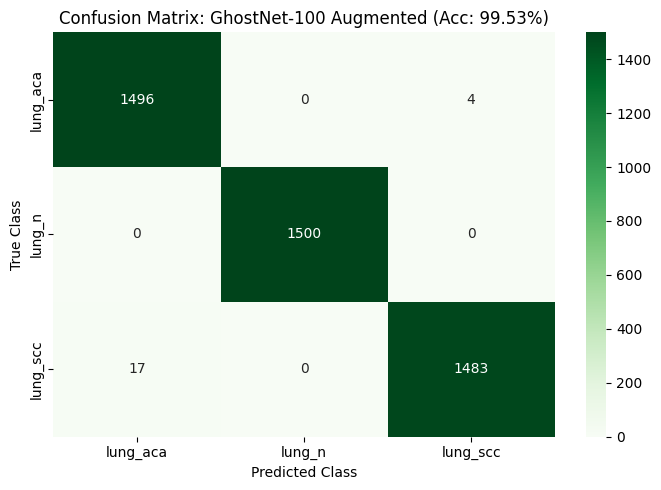

In [17]:
#cell 14
seed_everything(SEED)
model_aug = build_ghostnet100(num_classes=3)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=LR, betas=(BETA1, BETA2))

history_aug = train_model(
    model_aug,
    train_loader_aug,
    optimizer_aug,
    criterion,
    epochs=EPOCHS,
    desc="GhostNet-100 (Augmented - 21k Images)"
)
results_aug = evaluate_model(model_aug, test_loader)
print("\n" + "="*60)
print("EVALUATION METRICS: GHOSTNET-100 (AUGMENTED)")
print("="*60)
print(f"Test Accuracy                     : {results_aug['accuracy'] * 100:.4f}%")
print(f"Macro Precision                   : {results_aug['precision_macro'] * 100:.4f}%")
print(f"Macro Recall / Sensitivity        : {results_aug['recall_macro'] * 100:.4f}%")
print(f"Macro Specificity                 : {results_aug['specificity_macro'] * 100:.4f}%")
print(f"Macro F1-Score                    : {results_aug['f1_macro'] * 100:.4f}%")
print(f"Multiclass ROC-AUC (Macro OVR)    : {results_aug['roc_auc_macro']:.6f}")
print(f"Final Training Loss (Epoch {EPOCHS})     : {history_aug['train_loss'][-1]:.6f}")
print(f"Average Epoch Training Time       : {np.mean(history_aug['epoch_times']):.2f} s")
print(f"Average Inference Time Per Image  : {results_aug['avg_inference_time_ms']:.4f} ms")

# Save checkpoint
torch.save(model_aug.state_dict(), "ghostnet_100_augmented.pth")
print("\n[SAVED] Saved augmented model to 'ghostnet_100_augmented.pth'")

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    results_aug['confusion_matrix'],
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=True
)
plt.title(f"Confusion Matrix: GhostNet-100 Augmented (Acc: {results_aug['accuracy']*100:.2f}%)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig("confusion_matrix_aug.png", dpi=300)
plt.show()

In [18]:
paper_acc_aug = 99.96
comparison_data = [
    {
        "Metric": "Training Set Size",
        "Non-Augmented (Ours)": f"{len(train_paths):,}",
        "Augmented (Ours)": f"{len(train_dataset_augmented_doubled):,}",
        "Paper (Non-Aug)": "10,500",
        "Paper (Aug)": "21,000"
    },
    {
        "Metric": "Test Set Size",
        "Non-Augmented (Ours)": f"{len(test_paths):,}",
        "Augmented (Ours)": f"{len(test_paths):,}",
        "Paper (Non-Aug)": "4,500",
        "Paper (Aug)": "4,500"
    },
    {
        "Metric": "Test Accuracy (%)",
        "Non-Augmented (Ours)": f"{results_nonaug['accuracy']*100:.4f}%",
        "Augmented (Ours)": f"{results_aug['accuracy']*100:.4f}%",
        "Paper (Non-Aug)": f"{paper_acc_nonaug:.2f}%",
        "Paper (Aug)": f"{paper_acc_aug:.2f}%"
    },
    {
        "Metric": "Macro Precision (%)",
        "Non-Augmented (Ours)": f"{results_nonaug['precision_macro']*100:.4f}%",
        "Augmented (Ours)": f"{results_aug['precision_macro']*100:.4f}%",
        "Paper (Non-Aug)": "~99.95%",
        "Paper (Aug)": "~99.96%"
    },
    {
        "Metric": "Macro Recall / Sensitivity (%)",
        "Non-Augmented (Ours)": f"{results_nonaug['recall_macro']*100:.4f}%",
        "Augmented (Ours)": f"{results_aug['recall_macro']*100:.4f}%",
        "Paper (Non-Aug)": "~99.95%",
        "Paper (Aug)": "~99.96%"
    },
    {
        "Metric": "Macro Specificity (%)",
        "Non-Augmented (Ours)": f"{results_nonaug['specificity_macro']*100:.4f}%",
        "Augmented (Ours)": f"{results_aug['specificity_macro']*100:.4f}%",
        "Paper (Non-Aug)": "N/A",
        "Paper (Aug)": "N/A"
    },
    {
        "Metric": "Macro F1-Score (%)",
        "Non-Augmented (Ours)": f"{results_nonaug['f1_macro']*100:.4f}%",
        "Augmented (Ours)": f"{results_aug['f1_macro']*100:.4f}%",
        "Paper (Non-Aug)": "~99.95%",
        "Paper (Aug)": "~99.96%"
    },
    {
        "Metric": "Multiclass ROC-AUC (OVR)",
        "Non-Augmented (Ours)": f"{results_nonaug['roc_auc_macro']:.6f}",
        "Augmented (Ours)": f"{results_aug['roc_auc_macro']:.6f}",
        "Paper (Non-Aug)": "N/A",
        "Paper (Aug)": "N/A"
    },
    {
        "Metric": "Final Training Loss",
        "Non-Augmented (Ours)": f"{history_nonaug['train_loss'][-1]:.6f}",
        "Augmented (Ours)": f"{history_aug['train_loss'][-1]:.6f}",
        "Paper (Non-Aug)": "N/A",
        "Paper (Aug)": "N/A"
    },
    {
        "Metric": "Avg Epoch Training Time (s)",
        "Non-Augmented (Ours)": f"{np.mean(history_nonaug['epoch_times']):.2f}",
        "Augmented (Ours)": f"{np.mean(history_aug['epoch_times']):.2f}",
        "Paper (Non-Aug)": "N/A",
        "Paper (Aug)": "N/A"
    },
    {
        "Metric": "Avg Inference Time / Image (ms)",
        "Non-Augmented (Ours)": f"{results_nonaug['avg_inference_time_ms']:.4f}",
        "Augmented (Ours)": f"{results_aug['avg_inference_time_ms']:.4f}",
        "Paper (Non-Aug)": "N/A",
        "Paper (Aug)": "N/A"
    }
]

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("SIDE-BY-SIDE EXPERIMENTAL REPRODUCTION COMPARISON")
print("="*80)
print(df_comparison.to_string(index=False))
print("="*80)

# Save exports
df_comparison.to_csv("baseline_reproduction_comparison.csv", index=False)

df_history = pd.DataFrame({
    "epoch": range(1, EPOCHS + 1),
    "nonaug_train_loss": history_nonaug['train_loss'],
    "nonaug_train_acc": history_nonaug['train_acc'],
    "nonaug_epoch_time_s": history_nonaug['epoch_times'],
    "aug_train_loss": history_aug['train_loss'],
    "aug_train_acc": history_aug['train_acc'],
    "aug_epoch_time_s": history_aug['epoch_times']
})
df_history.to_csv("training_history.csv", index=False)
print("\n[EXPORT] Experimental results saved to 'baseline_reproduction_comparison.csv' and 'training_history.csv'")


SIDE-BY-SIDE EXPERIMENTAL REPRODUCTION COMPARISON
                         Metric Non-Augmented (Ours) Augmented (Ours) Paper (Non-Aug) Paper (Aug)
              Training Set Size               10,500           21,000          10,500      21,000
                  Test Set Size                4,500            4,500           4,500       4,500
              Test Accuracy (%)             97.6667%         99.5333%          99.95%      99.96%
            Macro Precision (%)             97.6963%         99.5358%         ~99.95%     ~99.96%
 Macro Recall / Sensitivity (%)             97.6667%         99.5333%         ~99.95%     ~99.96%
          Macro Specificity (%)             98.8333%         99.7667%             N/A         N/A
             Macro F1-Score (%)             97.6650%         99.5333%         ~99.95%     ~99.96%
       Multiclass ROC-AUC (OVR)             0.998685         0.999948             N/A         N/A
            Final Training Loss             0.072136         0.0590

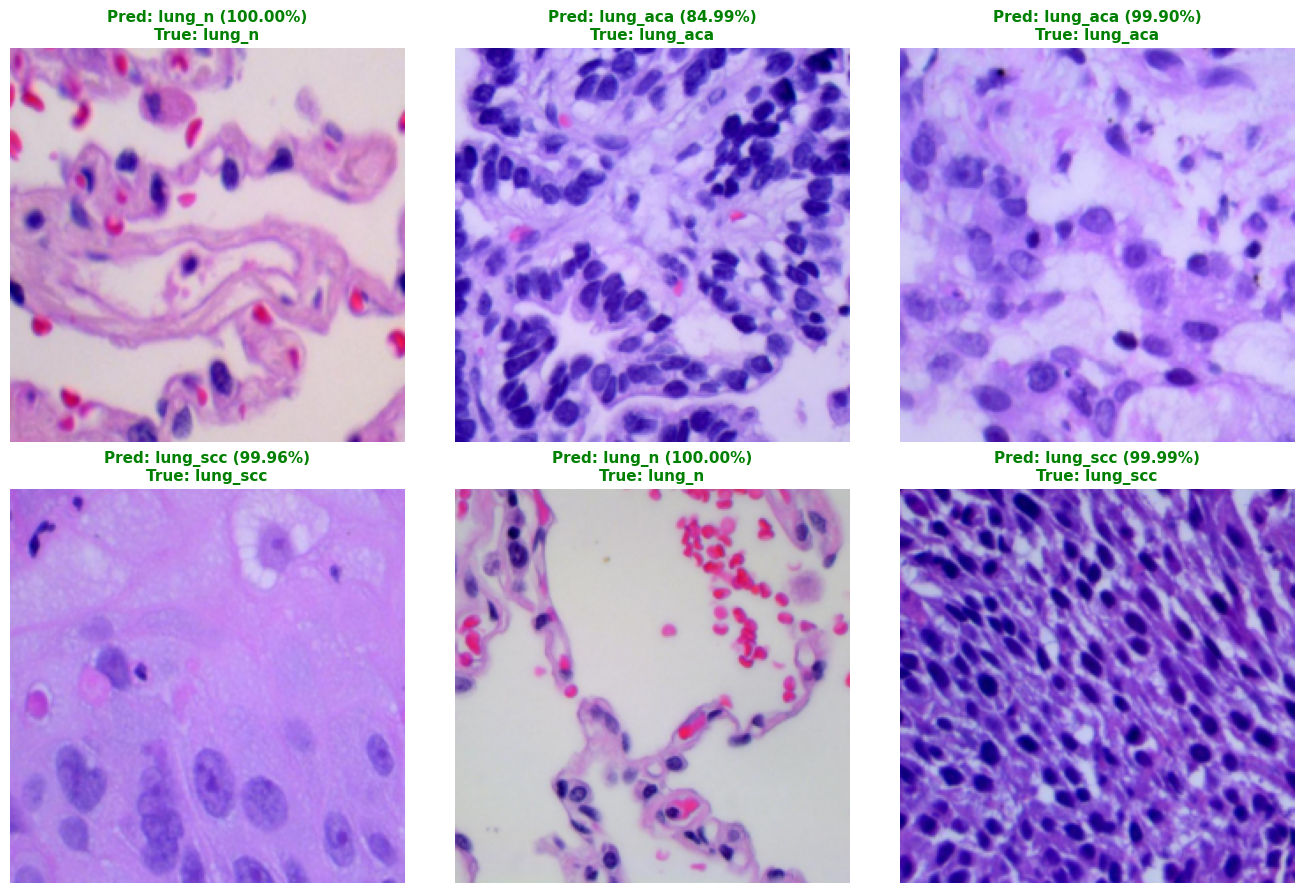

In [19]:
# ==============================================================================
# VISUALIZE MODEL PREDICTIONS ON RANDOM TEST SAMPLES
# ==============================================================================
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_test_predictions(model, dataset, num_samples=6, cols=3):
    model.eval()
    rows = (num_samples + cols - 1) // cols
    
    # Pick random indices from the test dataset
    indices = random.sample(range(len(dataset)), num_samples)
    
    # Normalization constants used during training
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4.5))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, true_label_idx = dataset[idx]
            
            # Run forward inference
            input_tensor = img_tensor.unsqueeze(0).to(device)
            logits = model(input_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred_label_idx = int(np.argmax(probs))
            confidence = probs[pred_label_idx] * 100.0
            
            # Denormalize image back to standard RGB range [0, 1] for visualization
            img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
            img_np = std * img_np + mean
            img_np = np.clip(img_np, 0.0, 1.0)
            
            true_name = IDX_TO_CLASS[int(true_label_idx)]
            pred_name = IDX_TO_CLASS[pred_label_idx]
            is_correct = (true_name == pred_name)
            
            # Plot
            axes[i].imshow(img_np)
            title_color = "green" if is_correct else "red"
            axes[i].set_title(
                f"Pred: {pred_name} ({confidence:.2f}%)\nTrue: {true_name}",
                fontsize=11,
                fontweight="bold",
                color=title_color
            )
            axes[i].axis("off")
            
    # Hide unused subplot slots
    for j in range(num_samples, len(axes)):
        axes[j].axis("off")
        
    plt.tight_layout()
    plt.show()

# Run on the non-augmented trained model
visualize_test_predictions(model_nonaug, test_dataset, num_samples=6, cols=3)